Przygotowanie danych do regresji

In [1]:
SEED = 2137

import pandas as pd
import numpy as np

data = pd.read_csv("data/regresja/domy.csv", decimal='.')
data[data == '?'] = pd.NA
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Id             1460 non-null   int64
 1   MSSubClass     1460 non-null   int64
 2   MSZoning       1460 non-null   str  
 3   LotFrontage    1201 non-null   str  
 4   LotArea        1460 non-null   int64
 5   Street         1460 non-null   str  
 6   Alley          91 non-null     str  
 7   LotShape       1460 non-null   str  
 8   LandContour    1460 non-null   str  
 9   Utilities      1460 non-null   str  
 10  LotConfig      1460 non-null   str  
 11  LandSlope      1460 non-null   str  
 12  Neighborhood   1460 non-null   str  
 13  Condition1     1460 non-null   str  
 14  Condition2     1460 non-null   str  
 15  BldgType       1460 non-null   str  
 16  HouseStyle     1460 non-null   str  
 17  OverallQual    1460 non-null   int64
 18  OverallCond    1460 non-null   int64
 19  YearBuilt      14

In [2]:
data = data.drop("Id", axis="columns")
data = data[data["GrLivArea"] < 4_000]

In [3]:
def fill_missing(column, method='interp'):
    if method == 'fill':
        data[column] = data[column].ffill()
        data[column] = data[column].bfill()
    else:
        data[column] = data[column].interpolate()

def qual_to_val(column):
    qual_to_val = {"Ex": "6", "Gd": "5", "TA": "4", "Fa": "3", "Po": "2", "NA": "0", pd.NA: "0"}
    data[column] = data[column].map(qual_to_val)
    data[column] = pd.to_numeric(data[column])
    fill_missing(column)

for col in ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC", "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]:
    qual_to_val(col)

def pytajniki(column):
    data[column] = pd.to_numeric(data[column])
    fill_missing(column)

for col in ["LotFrontage", "MasVnrArea", "GarageYrBlt"]:
    pytajniki(col)

data["MSSubClass"] = data["MSSubClass"].astype(str)

data = pd.get_dummies(data, dtype=int)

In [4]:
y = data["SalePrice"]
X = data.drop("SalePrice", axis="columns")

In [5]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, accuracy_score

reg = linear_model.LinearRegression()
_ = reg.fit(X, y)

y_pred = reg.predict(X)
mean_squared_error(y, y_pred)

397772738.1523051

In [6]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, accuracy_score

reg = linear_model.Ridge(alpha=.5)
_ = reg.fit(X, y)

y_pred = reg.predict(X)
mean_squared_error(y, y_pred)

402825966.30167043

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=SEED)
reg = linear_model.Ridge(alpha=.5)
_ = reg.fit(X_train, y_train)
print(reg.score(X_test, y_test))
y_pred_ridge = reg.predict(X_test)

reg = linear_model.LinearRegression()
_ = reg.fit(X_train, y_train)
print(reg.score(X_test, y_test))

y_pred_linear = reg.predict(X_test)

0.8850087245097047
0.870451647658413


In [8]:
from random import random, randint
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV

reg = linear_model.Ridge(alpha=1.0)
result = cross_validate(reg, X, y)
print(result["test_score"])
print(sum(result["test_score"]) / 5)

[0.88029031 0.9100342  0.89226501 0.8807519  0.87759824]
0.8881879310055488


In [9]:
from sklearn.model_selection import train_test_split, cross_validate

reg = linear_model.LinearRegression()
result = cross_validate(reg, X, y)
print(result["test_score"])
print(sum(result["test_score"]) / 5)

[0.87015749 0.90624012 0.873692   0.86883562 0.8680085 ]
0.8773867473826653


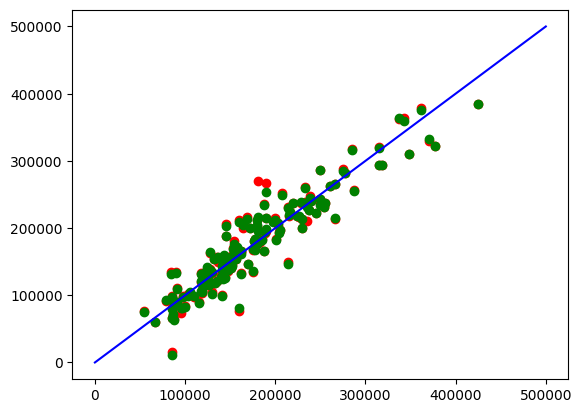

In [10]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred_linear, color="red")
plt.scatter(y_test, y_pred_ridge, color="green")

plt.plot([0, 500_000], [0, 500_000], color="blue")
plt.show()